<a href="https://colab.research.google.com/github/gilIolgenblum/ProteinCrowding/blob/main/tutorials/06_exporting_results_and_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exporting Results and Publication Figures

## Goal
In this final tutorial, you will learn how to extract the underlying thermodynamic arrays from the model objects and export them for external plotting software (like Origin or GraphPad Prism).
You will also learn how to tweak the `matplotlib` properties of the `BinaryPlotter` and `TernaryPlotter` for manuscript-quality figures.

## Setup

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/ProteinCrowding.git
    # Change the working directory to the repository root
    os.chdir('/content/ProteinCrowding')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/ProteinCrowding/src')

Cloning into 'ProteinCrowding'...
remote: Enumerating objects: 468, done.
remote: Counting objects: 100% (468/468), done.
remote: Compressing objects: 100% (284/284), done.
remote: Total 468 (delta 240), reused 384 (delta 179), pack-reused 0 (from 0)
Receiving objects: 100% (468/468), 16.75 MiB | 19.75 MiB/s, done.
Resolving deltas: 100% (240/240), done.
Obtaining file:///content/ProteinCrowding
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fh_crowding (pyproject.toml) ... done
  Created wheel for fh_crowding: filename=fh_crowding-0.1.0-0.editable-py3-none-any.whl size=3165 sha256=864295948f9c61da3b794a4f6e03cd802c3d6bc799a74ddc1fa4b1c6f056e185
  Stored in directory: /tmp/pip-ephem-wheel-cache-t5wntmds/wheels/8e/87/c6/59b0297bcdbde056eefb789604b557fd569845c8580cefb7a2
Successfully built fh_crowding


In [2]:
import fh_crowding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Module imported successfully: {fh_crowding.__name__}")

Module imported successfully: fh_crowding


## Exporting Data Arrays
The model class structures keep all thermodynamic outputs stored as numpy arrays. For a binary model, these are 1D arrays. For a ternary model, these are 2D arrays.

Let's run a quick binary simulation to generate some data.

In [3]:
model = fh_crowding.BinaryCrowdingModel(
    protein=fh_crowding.Protein(SASA=1800.0),
    cosolute=fh_crowding.Cosolute(nu=2.479, chi=0.610, chiTS=-3.650),
    eps=-0.5,
    epsTS=0.0,
    phiC_max=0.1,
    dphiC=0.005,
    T=298.15
)
model.solve_equil()

### Method 1: Using `to_pandas()`
The easiest way is to let the model generate a DataFrame for you.

In [4]:
# This method populates the model.results attribute
model.to_pandas()
df = model.results

display(df.head())

# To export this dataframe:
# df.to_csv("my_binary_data.csv", index=False)

,phiC,phiCsurf,phiS,phiSsurf,molar,molal,osm,gamma_per_vol,gamma,gammaC_per_vol,...,ddA_chi_kJ,ddA_eps_kJ,ddA_kJ,ddE_chi_kJ,ddE_eps_kJ,ddE_kJ,TddS_nu_kJ,TddS_chi_kJ,TddS_eps_kJ,TddS_kJ
0,0.0001,0.000217,0.9999,0.999783,0.002241,0.002241,0.002241,1.172662,295.885342,-0.000047,...,0.000005,0.050203,0.029586,-0.000026,0.050203,0.050177,0.020622,-0.000031,0.0,0.020591
1,0.0051,0.011088,0.9949,0.988912,0.114293,0.114879,0.114137,1.174115,296.251868,-0.002428,...,0.013680,2.562079,1.510156,-0.068176,2.562079,2.493903,1.065603,-0.081856,0.0,0.983747
2,0.0101,0.021968,0.9899,0.978032,0.226346,0.228655,0.225742,1.175067,296.492128,-0.004836,...,0.053739,5.076143,2.993004,-0.267816,5.076143,4.808327,2.136878,-0.321556,0.0,1.815323
3,0.0151,0.032850,0.9849,0.967150,0.338398,0.343586,0.337069,1.175499,296.601153,-0.007270,...,0.120205,7.590593,4.477802,-0.599056,7.590593,6.991537,3.232997,-0.719261,0.0,2.513735
4,0.0201,0.043725,0.9799,0.956275,0.450450,0.459690,0.448134,1.175393,296.574375,-0.009726,...,0.212953,10.103542,5.964191,-1.061273,10.103542,9.042268,4.352303,-1.274226,0.0,3.078077


### Method 2: Manual Extraction
If you only need specific arrays (e.g., just the volume fractions and the Free Energy), you can extract them directly.
Remember that the model operates natively in Volume Fraction ($\phi$). To get Molal or Molar, you must extract `model.molal` or `model.molar` respectively.

In [5]:
custom_df = pd.DataFrame({
    "phi": model.phiC,
    "molal": model.molal,
    "dG_kJ": model.ddA_kj,
    "dG_kcal": model.ddA_kj / 4.184
})

display(custom_df.head())

,phi,molal,dG_kJ,dG_kcal
0,0.0001,0.002241,0.029586,0.007071
1,0.0051,0.114879,1.510156,0.360936
2,0.0101,0.228655,2.993004,0.715345
3,0.0151,0.343586,4.477802,1.070220
4,0.0201,0.459690,5.964191,1.425476


## Customizing Built-In Plots
The `fh_crowding.plotting` classes use `matplotlib` under the hood. They typically return a `matplotlib.figure.Figure` object and access the current axes (`plt.gca()`), allowing you to easily tweak labels, fonts, and limits after calling the plot function.

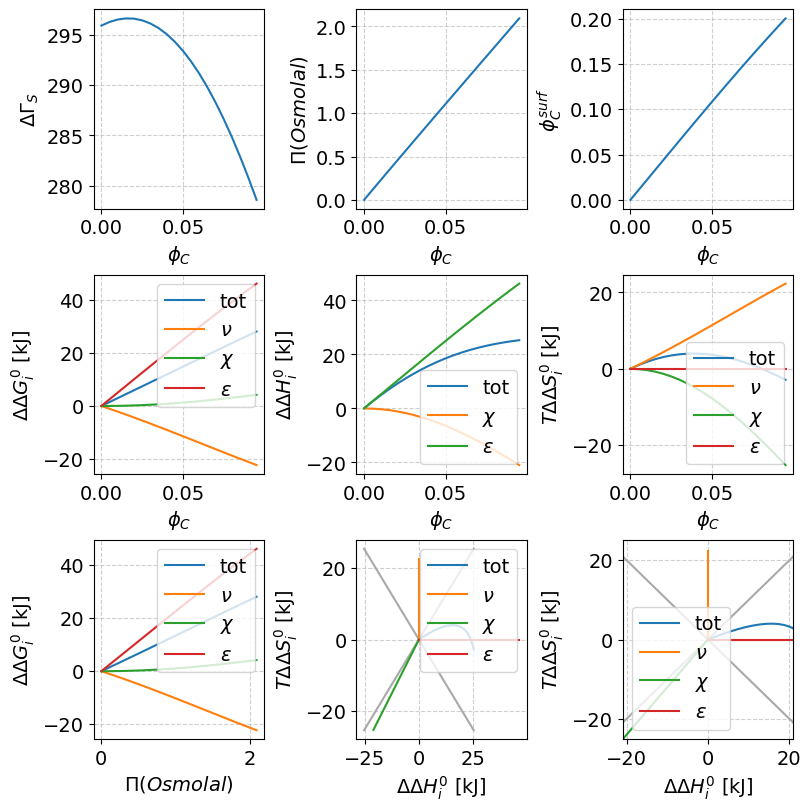

In [6]:
from fh_crowding.plotting import BinaryPlotter

# Create the plotter
plotter = BinaryPlotter(model)

# Set a publication-ready style or tweak rcParams
plt.rcParams.update({'font.size': 14, 'font.family': 'sans-serif'})

# plot_results returns a figure
fig = plotter.plot_results()

# We can access the axes from the figure
axes = fig.axes

# Add a grid to all axes
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6)

# Save the figure to a high-res PDF or PNG
# plt.savefig("publication_figure.png", dpi=300, bbox_inches='tight')
plt.show()

## Conclusion
Congratulations! You've reached the end of the `ProteinCrowding` tutorials.

You can now:
- Run binary and ternary simulations.
- Fit complex soft interaction parameters to empirical data.
- Analyze the physical drivers behind protein stabilization and destabilization.
- Export your results and figures for your manuscripts.